# Question Answering

Time to look at question answering! This task comes in many flavors, but the one we’ll focus on in this section is called extractive question answering. This involves posing questions about a document and identifying the answers as spans of text in the document itself.



We will fine-tune a BERT model on the SQuAD dataset, which consists of questions posed by crowdworkers on a set of Wikipedia articles. This will give us a model able to compute predictions.

## 1. Preparing the data

The dataset that is used the most as an academic benchmark for extractive question answering is SQuAD, so that’s the one we’ll use here. There is also a harder SQuAD v2 benchmark, which includes questions that don’t have an answer. As long as your own dataset contains a column for contexts, a column for questions, and a column for answers, you should be able to adapt the steps below.



### 1.1. The SQuAD dataset

In [1]:
!pip install datasets evaluate transformers[sentencepiece]
!pip install accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.0 MB/s eta 0:00:00


In [2]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
token = user_secrets.get_secret("HF_TOKEN")
login(token=token)

As usual, we can download and cache the dataset in just one step thanks to `load_dataset()`:



In [3]:
from datasets import load_dataset

raw_datasets = load_dataset('squad')

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

We can then have a look at this object to learn more about the SQuAD dataset:



In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 87599
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 10570
    })
})

It looks like we have everything we need with the `context`, `question`, and `answers` fields, so let’s print those for the first element of our training set:



In [5]:
print("Context: ", raw_datasets["train"][0]["context"])
print("Question: ", raw_datasets["train"][0]["question"])
print("Answer: ", raw_datasets["train"][0]["answers"])

Context:  Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a direct line that connects through 3 statues and the Gold Dome), is a simple, modern stone statue of Mary.
Question:  To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Answer:  {'text': ['Saint Bernadette Soubirous'], 'answer_start': [515]}


The `context` and `question` fields are very straightforward to use. The `answers` field is a bit trickier as it comports a dictionary with two fields that are both lists. This is the format that will be expected by the `squad` metric during evaluation; if you are using your own data, you don’t necessarily need to worry about putting the answers in the same format. The `text` field is rather obvious, and the `answer_start` field contains the starting character index of each answer in the context.



During training, there is only one possible answer. We can double-check this by using the `Dataset.filter()` method:



In [6]:
raw_datasets["train"].filter(lambda x: len(x["answers"]["text"]) != 1)

Filter:   0%|          | 0/87599 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'title', 'context', 'question', 'answers'],
    num_rows: 0
})

For evaluation, however, there are several possible answers for each sample, which may be the same or different:



In [7]:
print(raw_datasets["validation"][0]["answers"])
print()
raw_datasets["validation"][0]["context"]

{'text': ['Denver Broncos', 'Denver Broncos', 'Denver Broncos'], 'answer_start': [177, 177, 177]}



'Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015 season. The American Football Conference (AFC) champion Denver Broncos defeated the National Football Conference (NFC) champion Carolina Panthers 24–10 to earn their third Super Bowl title. The game was played on February 7, 2016, at Levi\'s Stadium in the San Francisco Bay Area at Santa Clara, California. As this was the 50th Super Bowl, the league emphasized the "golden anniversary" with various gold-themed initiatives, as well as temporarily suspending the tradition of naming each Super Bowl game with Roman numerals (under which the game would have been known as "Super Bowl L"), so that the logo could prominently feature the Arabic numerals 50.'

We won’t dive into the evaluation script as it will all be wrapped up by a 🤗 Datasets metric for us, but the short version is that some of the questions have several possible answers, and this script will compare a predicted answer to all the acceptable answers and take the best score. 

### 1.2. Processing the training data


Let’s start with preprocessing the training data. The hard part will be to generate labels for the question’s answer, which will be the start and end positions of the tokens corresponding to the answer inside the context.



But let’s not get ahead of ourselves. First, we need to convert the text in the input into IDs the model can make sense of, using a tokenizer:



In [8]:
from transformers import AutoTokenizer

checkpoint = "bert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

We can pass to our tokenizer the question and the context together, and it will properly insert the special tokens to form a sentence like this:



<pre> [CLS] question [SEP] context [SEP] </pre>


Let’s double-check:



In [9]:
context = raw_datasets["train"][0]["context"]
question = raw_datasets["train"][0]["question"]
print(context)
print(question)

inputs = tokenizer(question, context)
tokenizer.decode(inputs["input_ids"])

Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a direct line that connects through 3 statues and the Gold Dome), is a simple, modern stone statue of Mary.
To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?


'[CLS] To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France? [SEP] Architecturally, the school has a Catholic character. Atop the Main Building \' s gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend " Venite Ad Me Omnes ". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive ( and in a direct line that connects through 3 statues and the Gold Dome ), is a simple, modern stone statue of Mary. [SEP]'

The labels will then be the index of the tokens starting and ending the answer, and the model will be tasked to predicted one start and end logit per token in the input, with the theoretical labels being as follow:



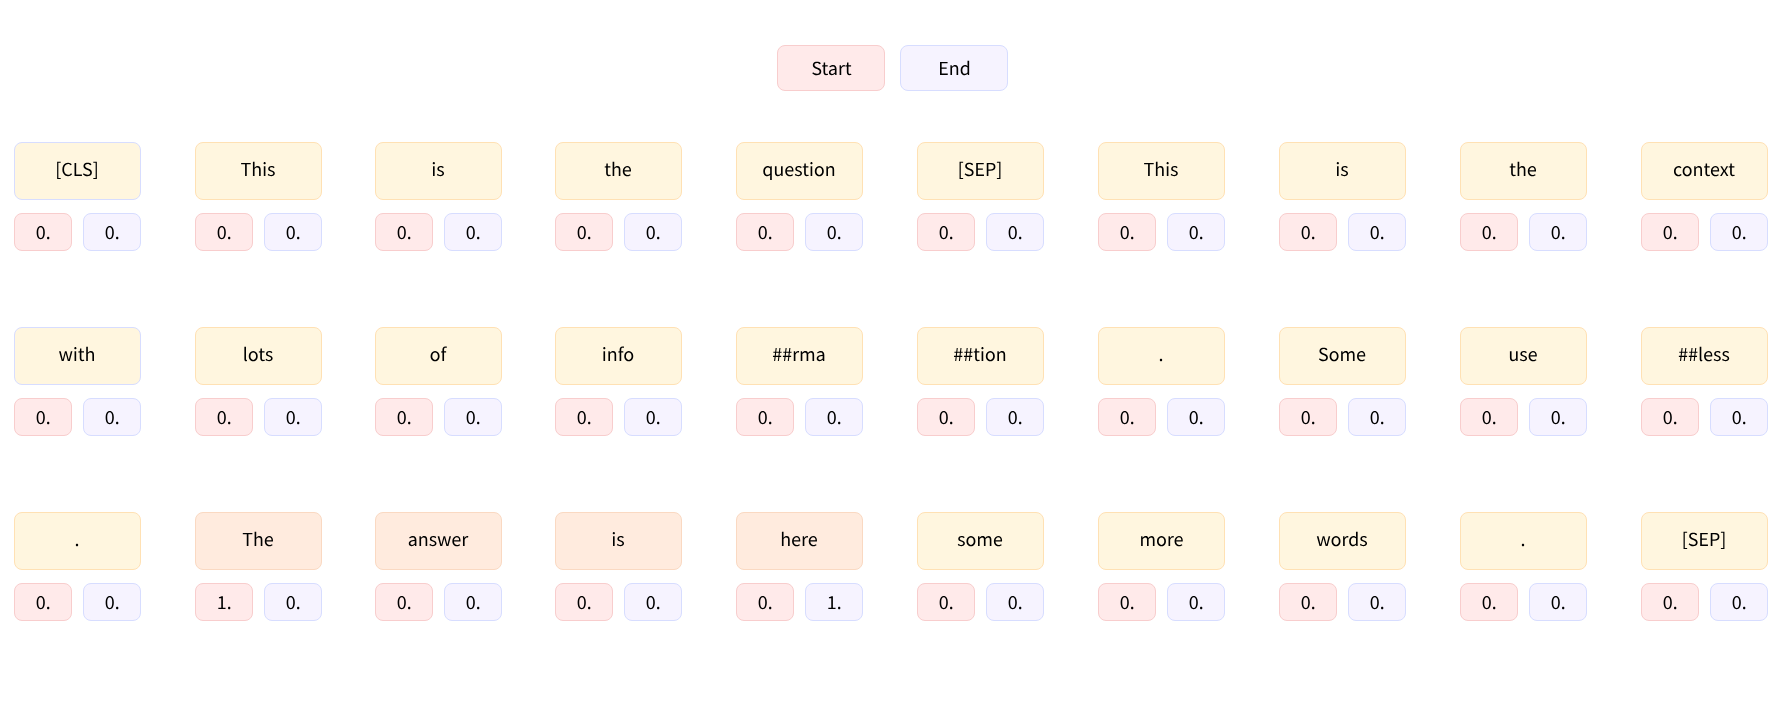

In this case the context is not too long, but some of the examples in the dataset have very long contexts that will exceed the maximum length we set (which is 384 in this case). We will deal with long contexts by creating several training features from one sample of our dataset, with a sliding window between them.

To see how this works using the current example, we can limit the length to 100 and use a sliding window of 50 tokens. As a reminder, we use:



* `max_length` to set the maximum length (here 100)

* `truncation="only_second"` to truncate the context (which is in the second position) when the question with its context is too long

* `stride` to set the number of overlapping tokens between two successive chunks (here 50)

* `return_overflowing_tokens=True` to let the tokenizer know we want the overflowing tokens

In [10]:
inputs = tokenizer(
    question,
    context,
    max_length=100,
    stride=50,
    return_overflowing_tokens=True,
    truncation="only_second"
)

for ids in inputs["input_ids"]:
    print(tokenizer.decode(ids))
    print()

[CLS] To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France? [SEP] Architecturally, the school has a Catholic character. Atop the Main Building ' s gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend " Venite Ad Me Omnes ". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basi [SEP]

[CLS] To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France? [SEP] the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend " Venite Ad Me Omnes ". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin [SEP]

[CLS] To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France? [SEP] Next to the Main Building is t

As we can see, our example has been in split into four inputs, each of them containing the question and some part of the context. Note that the answer to the question (“Bernadette Soubirous”) only appears in the third and last inputs, so by dealing with long contexts in this way we will create some training examples where the answer is not included in the context. For those examples, the labels will be `start_position = end_position = 0` (so we predict the `[CLS]` token). We will also set those labels in the unfortunate case where the answer has been truncated so that we only have the start (or end) of it. For the examples where the answer is fully in the context, the labels will be the index of the token where the answer starts and the index of the token where the answer ends.



The dataset provides us with the start character of the answer in the context, and by adding the length of the answer, we can find the end character in the context. To map those to token indices, we will need to use the offset mappings. We can have our tokenizer return these by passing along `return_offsets_mapping=True`:



In [11]:
inputs = tokenizer(
    question,
    context,
    return_overflowing_tokens=True,
    return_offsets_mapping=True,
    max_length=100,
    stride=50,
    truncation="only_second"
)


As we can see, we get back the usual input IDs, token type IDs, and attention mask, as well as the offset mapping we required and an extra key, `overflow_to_sample_mapping`. The corresponding value will be of use to us when we tokenize several texts at the same time (which we should do to benefit from the fact that our tokenizer is backed by Rust). Since one sample can give several features, it maps each feature to the example it originated from. Because here we only tokenized one example, we get a list of `0`s:



But if we tokenize more examples, this will become more useful:



In [12]:
inputs = tokenizer(
    raw_datasets["train"][2:6]["question"],
    raw_datasets["train"][2:6]["context"],
    max_length=100,
    truncation="only_second",
    stride=50,
    return_overflowing_tokens=True,
    return_offsets_mapping=True,
)

print(f"The 4 examples gave {len(inputs['input_ids'])} features.")
print(f"Here is where each comes from: {inputs['overflow_to_sample_mapping']}.")

The 4 examples gave 19 features.
Here is where each comes from: [0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3].


As we can see, the first three examples (at indices 2, 3, and 4 in the training set) each gave four features and the last example (at index 5 in the training set) gave 7 features.



This information will be useful to map each feature we get to its corresponding label. As mentioned earlier, those labels are:



* `(0, 0)` if the answer is not in the corresponding span of the context

* `(start_position, end_position)` if the answer is in the corresponding span of the context, with `start_position` being the index of the token (in the input IDs) at the start of the answer and `end_position` being the index of the token (in the input IDs) where the answer ends.

To determine which of these is the case and, if relevant, the positions of the tokens, we first find the indices that start and end the context in the input IDs. We could use the token type IDs to do this, but since those do not necessarily exist for all models (DistilBERT does not require them, for instance), we’ll instead use the `sequence_ids()` method of the `BatchEncoding` our tokenizer returns.



Once we have those token indices, we look at the corresponding offsets, which are tuples of two integers representing the span of characters inside the original context. We can thus detect if the chunk of the context in this feature starts after the answer or ends before the answer begins (in which case the label is `(0, 0)`). If that’s not the case, we loop to find the first and last token of the answer.



One thing to keep in mind, we can group it in a function we will apply on the whole training dataset. We’ll pad every feature to the maximum length we set, as most of the contexts will be long (and the corresponding samples will be split into several features), so there is no real benefit to applying dynamic padding here:

In [13]:
max_length = 384
stride = 128

def preprocess_func(examples):
    answers = examples["answers"]
    questions = [q.strip() if isinstance(q, str) else q for q in examples["question"]]

    inputs = tokenizer(
        questions,
        examples["context"],
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        max_length=max_length,
        padding="max_length",
        stride=stride,
        truncation="only_second"
    )

    offset_mapping = inputs.pop("offset_mapping")
    sample_mapping = inputs.pop("overflow_to_sample_mapping")

    start_positions = []
    end_positions = []
    
    for i, offset in enumerate(offset_mapping):
        sample_idx = sample_mapping[i]
        answer = answers[sample_idx]
        # Only take into account the first answer in the answer list
        start_char = answer["answer_start"][0]
        end_char = start_char + len(answer["text"][0])
        sequence_ids = inputs.sequence_ids(i)

        # Find the start and end of the context
        idx = 0
        while sequence_ids[idx] != 1:
            idx += 1
        context_start = idx
        while sequence_ids[idx] == 1:
            idx += 1
        context_end = idx - 1

        # If the answer is not in the context
        if offset[context_start][0] > start_char or offset[context_end][1] < end_char:
            start_positions.append(0)
            end_positions.append(0)
        # If the answer is in the context
        else:
            # Find the index of the first token of the answer
            idx = context_start
            while idx <= context_end and offset[idx][0] <= start_char:
                idx += 1
            start_positions.append(idx - 1)

            idx = context_end
            while idx >= context_start and offset[idx][1] >= end_char:
                idx -= 1
            end_positions.append(idx + 1)
    
    inputs["start_positions"] = start_positions
    inputs["end_positions"] = end_positions
    return inputs

Note that we defined two constants to determine the maximum length used as well as the length of the sliding window, and that we added a tiny bit of cleanup before tokenizing: some of the questions in the SQuAD dataset have extra spaces at the beginning and the end that don’t add anything (and take up space when being tokenized if you use a model like RoBERTa), so we removed those extra spaces.



To apply this function to the whole training set, we use the `Dataset.map()` method with the `batched=True` flag. It’s necessary here as we are changing the length of the dataset (since one example can give several training features):



In [14]:
train_dataset = raw_datasets["train"].map(
    preprocess_func,
    batched=True,
    remove_columns=raw_datasets["train"].column_names
)
len(raw_datasets["train"]), len(train_dataset)

Map:   0%|          | 0/87599 [00:00<?, ? examples/s]

(87599, 88729)

### 1.3. Processing the validation data

Preprocessing the validation data will be slightly easier as we don’t need to generate labels (unless we want to compute a validation loss, but that number won’t really help us understand how good the model is). The real joy will be to interpret the predictions of the model into spans of the original context. For this, we will just need to store both the offset mappings and some way to match each created feature to the original example it comes from. Since there is an ID column in the original dataset, we’ll use that ID.



The only thing we’ll add here is a tiny bit of cleanup of the offset mappings. They will contain offsets for the question and the context, but once we’re in the post-processing stage we won’t have any way to know which part of the input IDs corresponded to the context and which part was the question (the `sequence_ids()` method we used is available for the output of the tokenizer only). So, we’ll set the offsets corresponding to the question to `None`:



In [15]:
def preprocess_validation_func(examples):
    questions = [q.strip() for q in examples["question"]]
    inputs = tokenizer(
        questions,
        examples["context"],
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        max_length=max_length,
        truncation="only_second",
        stride=stride,
        padding="max_length"
    )

    sample_mapping = inputs.pop("overflow_to_sample_mapping")
    example_ids = []

    for i in range(len(inputs["input_ids"])):
        sample_idx = sample_mapping[i]
        example_ids.append(examples["id"][sample_idx])
        sequence_ids = inputs.sequence_ids(i)
        offset = inputs["offset_mapping"][i]
        inputs["offset_mapping"][i] = [
            o if sequence_ids[k] == 1 else None for k, o in enumerate(offset)
        ]
    
    inputs["example_id"] = example_ids
    return inputs

We can apply this function on the whole validation dataset like before:



In [16]:
eval_dataset = raw_datasets["validation"].map(
    preprocess_validation_func,
    batched=True,
    remove_columns=raw_datasets["validation"].column_names
)
len(eval_dataset), len(raw_datasets["validation"])

Map:   0%|          | 0/10570 [00:00<?, ? examples/s]

(10822, 10570)

## 2. A custom training loop


The final format of the predicted answers is the one that will be expected by the metric we will use. As usual, we can load it with the help of the 🤗 Evaluate library:



In [17]:
import evaluate

metric = evaluate.load("squad")

Now let’s put everything we just did in a `compute_metrics()` function that we will use in our training loop. Normally, that `compute_metrics()` function only receives a tuple `eval_preds` with logits and labels. Here we will need a bit more, as we have to look in the dataset of features for the offset and in the dataset of examples for the original contexts.

In [18]:
from tqdm.auto import tqdm
import collections
import numpy as np

n_best = 20
max_answer_length = 40

def compute_metrics(start_logits, end_logits, features, examples):
    example_to_features = collections.defaultdict(list)
    for idx, feature in enumerate(features):
        example_to_features[feature["example_id"]].append(idx)
    
    predicted_answers = []
    for example in tqdm(examples):
        example_id = example["id"]
        context = example["context"]
        answers = []

        # Loop through all features associated with that example
        for feature_idx in example_to_features[example_id]:
            start_logit = start_logits[feature_idx]
            end_logit = end_logits[feature_idx]
            offsets = features[feature_idx]["offset_mapping"]

            start_indexes = np.argsort(start_logit)[-1: -n_best - 1: -1].tolist()
            end_indexes = np.argsort(end_logit)[-1: -n_best - 1: -1].tolist()

            for start_index in start_indexes:
                for end_index in end_indexes:
                    # Skip answers that are not fully in the context
                    if offsets[start_index] is None or offsets[end_index] is None:
                        continue
                    # Skip answers with a length < 0 or > max_answer_length
                    if (
                        start_index > end_index
                        or end_index - start_index + 1 > max_answer_length
                    ):
                        continue

                    answers.append(
                        {
                            "text": context[offsets[start_index][0]: offsets[end_index][1]],
                            "logit_score": start_logit[start_index] + end_logit[end_index]
                        }
                    )
        # Select the answer with the best score
        if len(answers) > 0:
            best_answer = max(answers, key=lambda x: x["logit_score"])
            predicted_answers.append(
                {"id": example_id, "prediction_text": best_answer["text"]}
            )
        else: 
            predicted_answers.append(
                {"id": example_id, "prediction_text": ""}
            )

    theoretical_answers = [{"id": ex["id"], "answers": ex["answers"]} for ex in examples]
    return metric.compute(predictions=predicted_answers, references=theoretical_answers)

### 2.1. Prepare everything for training

First we need to build the `DataLoaders` from our datasets. We set the format of those datasets to `"torch"`, and remove the columns in the validation set that are not used by the model. Then, we can use the `default_data_collator` provided by Transformers as a `collate_fn` and shuffle the training set, but not the validation set:



In [19]:
from torch.utils.data import DataLoader
from transformers import default_data_collator

train_dataset.set_format("torch")
eval_set = eval_dataset.remove_columns(["example_id", "offset_mapping"])
eval_set.set_format("torch")

train_dataloader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=default_data_collator
)

eval_dataloader = DataLoader(
    eval_set,
    batch_size=8,
    shuffle=False,
    collate_fn=default_data_collator
)

Next we reinstantiate our model, to make sure we’re not continuing the fine-tuning from before but starting from the BERT pretrained model again:



In [20]:
from transformers import AutoModelForQuestionAnswering

model = AutoModelForQuestionAnswering.from_pretrained(checkpoint)

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
qa_outputs.weight                          | MISSING    | 
qa_outputs.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized becaus

Then we will need an optimizer. As usual we use the classic `AdamW`, which is like Adam, but with a fix in the way weight decay is applied:



In [21]:
import torch

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

Once we have all those objects, we can send them to the `accelerator.prepare()` method. Remember that if you want to train on TPUs in a Colab notebook, you will need to move all of this code into a training function, and that shouldn’t execute any cell that instantiates an Accelerator. We can force mixed-precision training by passing `fp16=True` to the Accelerator (or, if you are executing the code as a script, just make sure to fill in the 🤗 Accelerate config appropriately).



In [22]:
from accelerate import Accelerator

accelerator = Accelerator(mixed_precision="fp16")
model, optimizer, train_dataloader, eval_dataloader = accelerator.prepare(
    model, optimizer, train_dataloader, eval_dataloader
)

As you should know from the previous sections, we can only use the `train_dataloader` length to compute the number of training steps after it has gone through the `accelerator.prepare()` method. We use the same linear schedule as in the previous sections:



In [23]:
from transformers import get_scheduler

num_train_epochs = 3
num_training_steps = len(train_dataloader) * num_train_epochs

lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_training_steps=num_training_steps,
    num_warmup_steps=0
)

To push our model to the Hub, we do these following steps:

In [24]:
from huggingface_hub import create_repo, get_full_repo_name, HfApi

model_name = "bert-finetuned-squad-accelerate"
repo_name = get_full_repo_name(model_name)
create_repo(repo_name, exist_ok=True)
api = HfApi()

In [25]:
output_dir = "bert-finetuned-squad-accelerate"

### 2.2. Training loop


We are now ready to write the full training loop. After defining a progress bar to follow how training goes, the loop has three parts:

* The training in itself, which is the classic iteration over the `train_dataloader`, forward pass through the model, then backward pass and optimizer step.

* The evaluation, in which we gather all the values for `start_logits` and `end_logits` before converting them to NumPy arrays. Once the evaluation loop is finished, we concatenate all the results. Note that we need to truncate because the Accelerator may have added a few samples at the end to ensure we have the same number of examples in each process.

* Saving and uploading, where we first save the model and the tokenizer

In [26]:
progress_bar = tqdm(range(num_training_steps))

for epoch in range(num_train_epochs):
    # Training
    model.train()
    for step, batch in enumerate(train_dataloader):
        outputs = model(**batch)
        loss = outputs.loss
        accelerator.backward(loss)

        accelerator.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        progress_bar.update(1)

    model.eval()
    start_logits = []
    end_logits = []
    for batch in tqdm(eval_dataloader):
        with torch.no_grad():
            outputs = model(**batch)

        start_logits.append(accelerator.gather(outputs.start_logits).cpu().numpy())
        end_logits.append(accelerator.gather(outputs.end_logits).cpu().numpy())

    start_logits = np.concatenate(start_logits)
    end_logits = np.concatenate(end_logits)
    start_logits = start_logits[: len(eval_dataset)]
    end_logits = end_logits[: len(eval_dataset)]

    result = compute_metrics(
        start_logits, 
        end_logits, 
        eval_dataset, 
        raw_datasets["validation"]
    )
    accelerator.print(f"epoch {epoch + 1}: {result}")

    # Save and upload
    accelerator.wait_for_everyone()
    unwrapped_model = accelerator.unwrap_model(model)
    unwrapped_model.save_pretrained(output_dir, save_function=accelerator.save)

    if accelerator.is_main_process:
        tokenizer.save_pretrained(output_dir)
        api.upload_folder(
            repo_id=repo_name,
            folder_path=output_dir,
            commit_message=f"Training progress in epoch {epoch}."
        )

  0%|          | 0/33276 [00:00<?, ?it/s]

  0%|          | 0/1353 [00:00<?, ?it/s]

  0%|          | 0/10570 [00:00<?, ?it/s]

epoch 1: {'exact_match': 80.1135288552507, 'f1': 87.63700574985812}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/10570 [00:00<?, ?it/s]

epoch 3: {'exact_match': 80.879848628193, 'f1': 88.51308208365747}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            